# **4 Proyek Automatidata**
**Analisis Regresi: Menyederhanakan hubungan data yang kompleks**

# Membangun Model Regresi Linier Berganda

Model regresi linier berganda membantu memperkirakan hubungan linier antara satu variabel dependen kontinu dan dua atau lebih variabel independen.

**Tujuan** proyek ini adalah untuk mendemonstrasikan pengetahuan tentang EDA dan model regresi linier berganda.

**Sasarannya** adalah untuk membangun model regresi linier berganda dan mengevaluasi model tersebut.

Aktivitas ini terdiri dari tiga bagian:

**Bagian 1:** EDA & Memeriksa Asumsi Model
* Apa saja tujuan EDA sebelum membangun model regresi linier berganda?

**Bagian 2:** Membangun dan mengevaluasi Model
* Sumber daya apa yang digunakan saat menyelesaikan tahap ini?

**Bagian 3:** Menginterpretasikan Hasil Model

* Wawasan utama apa yang muncul dari model?

* Rekomendasi bisnis apa yang diajukan berdasarkan model yang telah dibangun?

### Impor dan Pemuatan
Impor paket-paket yang telah diperlukan untuk membangun model regresi linier

In [ ]:
# Imports
# Packages untuk numerik + dataframe
import pandas as pd
import numpy as np

# Packages untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Packages untuk konversi tanggal guna menghitung durasi perjalanan
from datetime import datetime
from datetime import date
from datetime import timedelta

# Packages untuk OLS, MLR, confusion matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [ ]:
df0=pd.read_csv("/content/2017 Yellow Taxi Trip Data.csv")

**Tujuan EDA sebelum membangun model regresi linier berganda:**

1. Data pencilan dan nilai data ekstrem dapat secara signifikan memengaruhi persamaan regresi linier. Setelah memvisualisasikan data, dibuat rencana untuk mengatasi data pencilan dengan menghapus baris, mengganti data ekstrem dengan data rata-rata, dan/atau menghapus nilai data yang lebih besar dari 3 standar deviasi.

2. Aktivitas EDA juga mencakup identifikasi data yang hilang untuk membantu analis membuat keputusan tentang pengecualian atau penyertaan data tersebut dengan mengganti nilai dengan rata-rata, median, dan metode serupa lainnya.

3. Penting untuk memeriksa hal-hal seperti multikolinearitas antar variabel prediktor, serta memahami distribusinya, karena ini akan membantu memutuskan kesimpulan statistik apa yang dapat diambil dari model dan mana yang tidak.

4. Selain itu, akan bermanfaat untuk merekayasa fitur baru dengan mengalikan variabel atau mengambil selisih dari satu variabel ke variabel lainnya. Misalnya, dalam dataset ini dapat dibuat variabel `duration` dengan mengurangi `tpep_dropoff` dari `tpep_pickup time`.

### Jelajahi data dengan EDA

Menganalisis dan menemukan data, mencari korelasi, data yang hilang, outlier, dan duplikat.

In [ ]:
# Start with `.shape` and `.info()`

# Mempertahankan `df0` sebagai dataframe asli dan membuat salinannya (df) tempat perubahan akan dilakukan
# Mengembalikan `df` ke `df0` jika diperlukan di kemudian hari
df = df0.copy()

# Menampilkan dataset shape
print(df.shape)

# Menampilkan informasi dasar tentang dataset
df.info()

(22699, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  flo

Memeriksa data yang hilang dan data duplikat menggunakan `.isna()` dan `.drop_duplicates()`.

In [ ]:
# Memeriksa duplikat
print('Shape of dataframe:', df.shape)
print('Shape of dataframe with duplicates dropped:', df.drop_duplicates().shape)

# Memeriksa nilai yang hilang dalam dataframe
print('Total count of missing values:', df.isna().sum().sum())

# Menampilkan nilai yang hilang per kolom dalam dataframe
print('Missing values per column:')
df.isna().sum()

Shape of dataframe: (22699, 18)
Shape of dataframe with duplicates dropped: (22699, 18)
Total count of missing values: 0
Missing values per column:


,0
Unnamed: 0,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0


**Catatan:** Tidak ada data duplikat atau nilai yang hilang.

In [ ]:
# Menampilkan statistik deskriptif tentang data
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


**Catatan:** Beberapa hal menonjol dari tabel statistik ringkasan ini. Misalnya, jelas ada beberapa nilai pencilan pada beberapa variabel, seperti `tip_amount` (\$200) dan `total_amount` (\$1.200). Selain itu, sejumlah variabel, seperti `mta_tax`, tampaknya hampir konstan di seluruh data, yang menyiratkan bahwa variabel tersebut tidak diharapkan memiliki daya prediksi yang tinggi.

### Mengkonversi kolom pengambilan & pengantaran ke format tanggal dan waktu

In [ ]:
# Memeriksa format data
df['tpep_dropoff_datetime'][0]

'03/25/2017 9:09:47 AM'

In [ ]:
# Mengkonversi kolom tanggal ke datetime
# Menampilkan tipe data dari `tpep_pickup_datetime`, `tpep_dropoff_datetime`
print('Data type of tpep_pickup_datetime:', df['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime:', df['tpep_dropoff_datetime'].dtype)

# Mengkonversi `tpep_pickup_datetime` ke format datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Mengkonversi `tpep_dropoff_datetime` ke format datetime
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Menampilkan tipe data dari `tpep_pickup_datetime`, `tpep_dropoff_datetime`
print('Data type of tpep_pickup_datetime:', df['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime:', df['tpep_dropoff_datetime'].dtype)

df.head(3)

Data type of tpep_pickup_datetime: object
Data type of tpep_dropoff_datetime: object
Data type of tpep_pickup_datetime: datetime64[ns]
Data type of tpep_dropoff_datetime: datetime64[ns]


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75


### Membuat kolom durasi

Membuat kolom baru bernama `duration` yang mewakili total jumlah menit yang dibutuhkan untuk setiap perjalanan taksi.

In [ ]:
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])/np.timedelta64(1,'m')

### Outliers

Menggunakan `df.info()` untuk memeriksa kolom dan menentukan kolom mana yang perlu diperiksa untuk mencari outlier.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

Kolom terpenting yang perlu diperiksa untuk outlier adalah:
* `trip_distance`
* `fare_amount`
* `duration`



### Boxplot

Membuat boxplot untuk setiap fitur: `trip_distance`, `fare_amount`, `duration`.

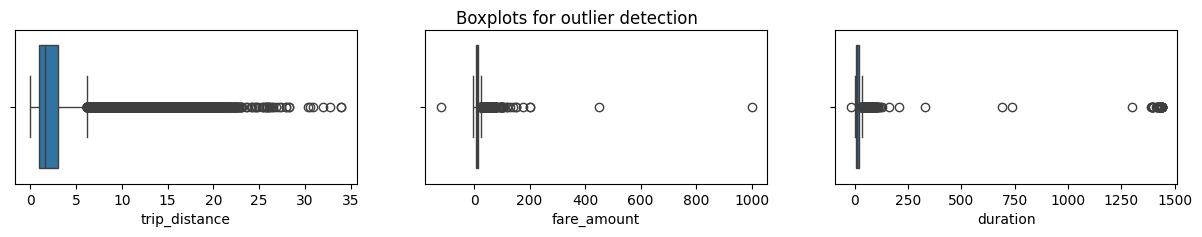

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2))
fig.suptitle('Boxplots for outlier detection')
sns.boxplot(ax=axes[0], x=df['trip_distance'])
sns.boxplot(ax=axes[1], x=df['fare_amount'])
sns.boxplot(ax=axes[2], x=df['duration'])
plt.show();

1. Ketiga variabel tersebut mengandung outlier. Beberapa ekstrem, tetapi yang lain tidak terlalu ekstrem.

2. Jarak dari ujung selatan Staten Island ke ujung utara Manhattan adalah 30 mil dan itu dalam garis lurus. Dengan pengetahuan ini dan distribusi nilai dalam kolom ini, wajar untuk membiarkan nilai-nilai ini apa adanya dan tidak mengubahnya. Namun, nilai untuk `fare_amount` dan `duration` tampaknya memiliki outlier yang bermasalah di ujung yang lebih tinggi.

3. Mungkin tidak untuk dua variabel terakhir, tetapi untuk `trip_distance` mungkin tidak apa-apa.

### Imputasi

#### `trip_distance` outlier

Berdasarkan dari ringkasan statistik terdapat jarak perjalanan 0. Apakah ini mencerminkan data yang salah, atau apakah itu perjalanan yang sangat pendek yang dibulatkan ke bawah?

Untuk memeriksanya, diurutkan nilai kolom, dihilangkan duplikat, dan diperiksa 10 nilai terkecil. Apakah itu nilai yang dibulatkan atau nilai yang tepat?

In [ ]:
# Apakah jarak tempuh 0 merupakan data yang buruk atau perjalanan yang sangat pendek dibulatkan ke bawah?
sorted(set(df['trip_distance']))[:10]

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

Jarak yang tercatat memiliki tingkat presisi yang tinggi. Namun, ada kemungkinan perjalanan memiliki jarak nol jika penumpang memesan taksi lalu berubah pikiran. Akan diperiksa apakah ada cukup nilai nol dalam data untuk menimbulkan masalah.

In [ ]:
# Menghitung jumlah perjalanan di mana `trip_distance` adalah nol
sum(df['trip_distance']==0)

148

**Catatan:** 148 dari sekitar 23.000 perjalanan relatif tidak signifikan. Dapat diisi dengan nilai 0.01, tetapi kemungkinan besar tidak akan banyak berpengaruh pada model. Oleh karena itu, kolom `trip_distance` akan tetap tidak berubah terkait dengan outlier.

#### `fare_amount` outliers

In [ ]:
df['fare_amount'].describe()

,fare_amount
count,22699.000000
mean,13.026629
std,13.243791
min,-120.000000
25%,6.500000
50%,9.500000
75%,14.500000
max,999.990000


**Contoh:**

Rentang nilai pada kolom `fare_amount` sangat besar dan nilai ekstremnya tidak masuk akal.

* **Nilai rendah:** Nilai negatif bermasalah. Nilai nol bisa saja sah jika taksi mencatat perjalanan yang langsung dibatalkan.

* **Nilai tinggi:** Jumlah tarif maksimum dalam dataset ini hampir \\$1.000, yang tampaknya sangat tidak mungkin. Nilai tinggi untuk fitur ini dapat dibatasi berdasarkan intuisi dan statistik. Rentang interkuartil (IQR) adalah \\$8. Rumus standar `Q3 + (1,5 * IQR)` menghasilkan \$26,50. Itu tampaknya tidak sesuai untuk batas tarif maksimum. Dalam hal ini, akan digunakan faktor `6`, yang menghasilkan batas \$62,50.

In [ ]:
# Imputasi nilai kurang dari $0 dengan `0`
df.loc[df['fare_amount'] < 0, 'fare_amount'] = 0
df['fare_amount'].min()

0.0

Memasukkan nilai maksimum sebagai `Q3 + (6 * IQR)`

In [ ]:
def outlier_imputer(column_list, iqr_factor):
    '''
    Mengisi nilai batas atas pada kolom yang ditentukan berdasarkan rentang interkuartilnya.

Argumen:
column_list: Daftar kolom yang akan diiterasi
iqr_factor: Angka yang mewakili x dalam rumus:

Q3 + (x * IQR). Digunakan untuk menentukan ambang batas maksimum,
di luar mana suatu titik dianggap sebagai outlier.

IQR dihitung untuk setiap kolom dalam column_list dan nilai yang melebihi
ambang batas atas untuk setiap kolom diisi dengan nilai ambang batas atas.
'''
    for col in column_list:
        # Menetapkan ulang nilai minimum menjadi nol
        df.loc[df[col] < 0, col] = 0

        # Menghitung ambang batas atas
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_threshold = q3 + (iqr_factor * iqr)
        print(col)
        print('q3:', q3)
        print('upper_threshold:', upper_threshold)

        # Tetapkan ulang nilai > ambang batas ke ambang batas
        df.loc[df[col] > upper_threshold, col] = upper_threshold
        print(df[col].describe())
        print()

In [ ]:
outlier_imputer(['fare_amount'], 6)

fare_amount
q3: 14.5
upper_threshold: 62.5
count    22699.000000
mean        12.897913
std         10.541137
min          0.000000
25%          6.500000
50%          9.500000
75%         14.500000
max         62.500000
Name: fare_amount, dtype: float64



#### `duration` outliers

In [ ]:
df['duration'].describe()

,duration
count,22699.000000
mean,17.013777
std,61.996482
min,-16.983333
25%,6.650000
50%,11.183333
75%,18.383333
max,1439.550000


Kolom `durasi` memiliki nilai bermasalah baik di ujung bawah maupun atas.

* **Nilai rendah:** Seharusnya tidak ada nilai yang mewakili waktu negatif. Maka diisi semua durasi negatif dengan `0`.

* **Nilai tinggi:** Mengisi nilai tinggi dengan cara yang sama seperti mengisi nilai outlier tertinggi untuk tarif: `Q3 + (6 * IQR)`.

In [ ]:
# Mengganti nilai negatif dengan nilai 0
df.loc[df['duration'] < 0, 'duration'] = 0
df['duration'].min()

0.0

In [ ]:
# Menginput nilai outlier yang tinggi
outlier_imputer(['duration'], 6)

duration
q3: 18.383333333333333
upper_threshold: 88.78333333333333
count    22699.000000
mean        14.460555
std         11.947043
min          0.000000
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: duration, dtype: float64



### Rekayasa fitur

#### Membuat kolom `mean_distance`

In [ ]:
# Membuat kolom `pickup_dropoff`
df['pickup_dropoff'] = df['PULocationID'].astype(str) + ' ' + df['DOLocationID'].astype(str)
df['pickup_dropoff'].head(2)

,pickup_dropoff
0,100 231
1,186 43


Sekarang, digunakan pernyataan `groupby()` untuk mengelompokkan setiap baris berdasarkan kolom `pickup_dropoff` yang baru, dihitung rata-ratanya, dan diambil nilai hanya di kolom `trip_distance`. Ditetapkan hasilnya ke variabel bernama `grouped`.

In [ ]:
grouped = df.groupby('pickup_dropoff').mean(numeric_only=True)[['trip_distance']]
grouped[:5]

,trip_distance
pickup_dropoff,
1 1,2.433333
10 148,15.700000
100 1,16.890000
100 100,0.253333
100 107,1.180000


In [ ]:
# 1. Mengkonversi `grouped` ke dalam dictionary
grouped_dict = grouped.to_dict()

# 2. Menetapkan ulang agar hanya berisi inner dictionary
grouped_dict = grouped_dict['trip_distance']

In [ ]:
# 1. Membuat kolom mean_distance yang merupakan salinan dari kolom helper pickup_dropoff.
df['mean_distance'] = df['pickup_dropoff']

# 2. Map `grouped_dict` ke kolom `mean_distance`
df['mean_distance'] = df['mean_distance'].map(grouped_dict)

# Mengkonfirmasi bahwa berhasil
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_distance']]

,mean_distance
0,3.521667
4909,3.521667
16636,3.521667
18134,3.521667
19761,3.521667
20581,3.521667


#### Membuat kolom `mean_duration`

Mengulangi proses yang digunakan untuk membuat kolom `mean_distance` untuk membuat kolom `mean_duration`.

In [ ]:
grouped = df.groupby('pickup_dropoff').mean(numeric_only=True)[['duration']]
grouped

# Membuat dictionary di mana kuncinya adalah lokasi penjemputan dan pengantaran yang unik dan nilainya adalah
# rata-rata durasi perjalanan untuk semua perjalanan dengan kombinasi lokasi penjemputan dan pengantaran tersebut
grouped_dict = grouped.to_dict()
grouped_dict = grouped_dict['duration']

df['mean_duration'] = df['pickup_dropoff']
df['mean_duration'] = df['mean_duration'].map(grouped_dict)

# Mengkonfirmasi
df[(df['PULocationID']==100) & (df['DOLocationID']==231)][['mean_duration']]

,mean_duration
0,22.847222
4909,22.847222
16636,22.847222
18134,22.847222
19761,22.847222
20581,22.847222


#### Membuat kolom `hari` dan `bulan`

Membuat dua kolom baru, `hari` (nama hari) dan `bulan` (nama bulan) dengan mengekstrak informasi yang relevan dari kolom `tpep_pickup_datetime`.

In [ ]:
# Membuat kolom 'day'
df['day'] = df['tpep_pickup_datetime'].dt.day_name().str.lower()

# Membuat kolom 'month'
df['month'] = df['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

#### Membuat kolom `rush_hour`

Mendefinisikan jam sibuk sebagai:
* Hari kerja apa pun (bukan Sabtu atau Minggu) dan
* Dari pukul 06:00–10:00 atau dari pukul 16:00–20:00

Membuat kolom biner `rush_hour` yang berisi angka 1 jika perjalanan dilakukan selama jam sibuk dan angka 0 jika tidak.

In [ ]:
# Membuat kolom 'rush_hour'
df['rush_hour'] = df['tpep_pickup_datetime'].dt.hour

# Jika harinya Sabtu atau Minggu, dimasukkan nilai 0 pada kolom `rush_hour`.
df.loc[df['day'].isin(['saturday', 'sunday']), 'rush_hour'] = 0

In [ ]:
def rush_hourizer(hour):
    if 6 <= hour['rush_hour'] < 10:
        val = 1
    elif 16 <= hour['rush_hour'] < 20:
        val = 1
    else:
        val = 0
    return val

In [ ]:
# Menerapkan fungsi `rush_hourizer()` ke kolom baru.
df.loc[(df.day != 'saturday') & (df.day != 'sunday'), 'rush_hour'] = df.apply(rush_hourizer, axis=1)
df.head()

/tmp/ipykernel_13239/3278249955.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 1 1 ... 1 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[(df.day != 'saturday') & (df.day != 'sunday'), 'rush_hour'] = df.apply(rush_hourizer, axis=1)


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.3,16.56,14.066667,100 231,3.521667,22.847222,saturday,mar,0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.3,20.80,26.500000,186 43,3.108889,24.470370,tuesday,apr,0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.3,8.75,7.200000,262 236,0.881429,7.250000,friday,dec,1
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.3,27.69,30.250000,188 97,3.700000,30.250000,sunday,may,0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.0,0.3,17.80,16.716667,4 112,4.435000,14.616667,saturday,apr,0


### Scatter plot

Membuat diagram sebar untuk memvisualisasikan hubungan antara `mean_duration` dan `fare_amount`

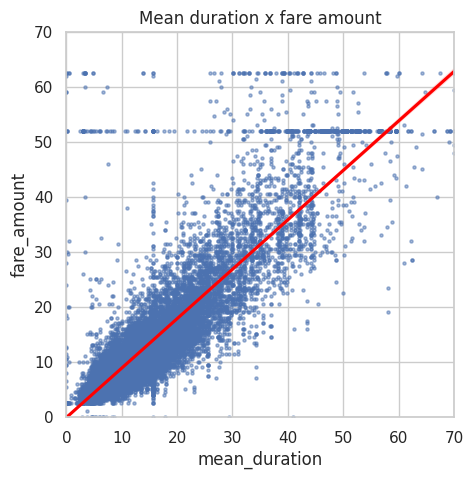

In [ ]:
# Membuat diagram sebar duration dan trip_distance, dengan garis yang paling sesuai
sns.set(style='whitegrid')
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(5)
sns.regplot(x=df['mean_duration'], y=df['fare_amount'],
            scatter_kws={'alpha':0.5, 's':5},
            line_kws={'color':'red'})
plt.ylim(0, 70)
plt.xlim(0, 70)
plt.title('Mean duration x fare amount')
plt.show()

Variabel `mean_duration` berkorelasi dengan variabel target. Tetapi terdapat garis horizontal di sekitar jumlah tarif 52 dolar dan 63 dolar.

Yang diwakili oleh salah satu garis tersebut, yaitu 62 dolar dan 50 sen adalah nilai maksimum yang diimputasi untuk outlier, jadi semua outlier sebelumnya sekarang akan memiliki jumlah tarif sebesar \$62,50.

Akan diperiksa nilai perjalanan pada garis horizontal kedua dalam diagram sebar.

In [ ]:
df[df['fare_amount'] > 50]['fare_amount'].value_counts().head()

,count
fare_amount,
52.0,514
62.5,84
59.0,9
50.5,9
57.5,8


**Catatan:** Terdapat 514 perjalanan dengan tarif $52.

Akan diperiksa 30 perjalanan pertama dari jumlah tersebut.

In [ ]:
# Mengatur pandas untuk menampilkan semua kolom.
pd.set_option('display.max_columns', None)
df[df['fare_amount']==52].head(30)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
11,18600059,2,2017-03-05 19:15:30,2017-03-05 19:52:18,2,18.90,2,N,236,132,1,52.0,0.0,0.5,14.58,5.54,0.3,72.92,36.800000,236 132,19.211667,40.500000,sunday,mar,0
110,47959795,1,2017-06-03 14:24:57,2017-06-03 15:31:48,1,18.00,2,N,132,163,1,52.0,0.0,0.5,0.00,0.00,0.3,52.80,66.850000,132 163,19.229000,52.941667,saturday,jun,0
161,95729204,2,2017-11-11 20:16:16,2017-11-11 20:17:14,1,0.23,2,N,132,132,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,0.966667,132 132,2.255862,3.021839,saturday,nov,0
247,103404868,2,2017-12-06 23:37:08,2017-12-07 00:06:19,1,18.93,2,N,132,79,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,29.183333,132 79,19.431667,47.275000,wednesday,dec,0
379,80479432,2,2017-09-24 23:45:45,2017-09-25 00:15:14,1,17.99,2,N,132,234,1,52.0,0.0,0.5,14.64,5.76,0.3,73.20,29.483333,132 234,17.654000,49.833333,sunday,sep,0
388,16226157,1,2017-02-28 18:30:05,2017-02-28 19:09:55,1,18.40,2,N,132,48,2,52.0,4.5,0.5,0.00,5.54,0.3,62.84,39.833333,132 48,18.761905,58.246032,tuesday,feb,1
406,55253442,2,2017-06-05 12:51:58,2017-06-05 13:07:35,1,4.73,2,N,228,88,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,15.616667,228 88,4.730000,15.616667,monday,jun,0
449,65900029,2,2017-08-03 22:47:14,2017-08-03 23:32:41,2,18.21,2,N,132,48,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,45.450000,132 48,18.761905,58.246032,thursday,aug,0
468,80904240,2,2017-09-26 13:48:26,2017-09-26 14:31:17,1,17.27,2,N,186,132,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,42.850000,186 132,17.096000,42.920000,tuesday,sep,0
520,33706214,2,2017-04-23 21:34:48,2017-04-23 22:46:23,6,18.34,2,N,132,148,1,52.0,0.0,0.5,5.00,0.00,0.3,57.80,71.583333,132 148,17.994286,46.340476,sunday,apr,0


Tampaknya hampir semua perjalanan dalam 30 baris pertama dengan tarif $52 dimulai atau berakhir di lokasi 132, dan semuanya memiliki `RatecodeID` 2.

Tidak ada alasan yang jelas mengapa PULocation 132 memiliki begitu banyak tarif sebesar 52. Tarif tersebut tampaknya terjadi pada hari yang berbeda, waktu yang berbeda, dengan kedua vendor, dan di semua bulan. Namun, ada banyak tarif tol sebesar 5,76 dan $5,54. Hal ini tampaknya menunjukkan bahwa lokasi 132 berada di area yang sering memerlukan tol untuk akses masuk dan keluar. Kemungkinan besar ini adalah bandara.

Kamus data menyatakan bahwa `RatecodeID` 2 menunjukkan perjalanan ke JFK, yaitu Bandara Internasional John F. Kennedy. Pencarian cepat di Google untuk "tarif tetap taksi kota New York $52" menunjukkan bahwa pada tahun 2017 (tahun data ini dikumpulkan) memang ada tarif tetap untuk perjalanan taksi antara bandara JFK (di Queens) dan Manhattan.

Karena `RatecodeID` diketahui dari kamus data, nilai untuk kode tarif ini dapat dimasukkan kembali ke dalam data setelah model membuat prediksinya. Dengan cara ini diketahui bahwa titik data tersebut akan selalu benar.

### Mengisolasi variabel pemodelan

Menghapus fitur yang berlebihan, tidak relevan, atau yang tidak akan tersedia di lingkungan yang diterapkan.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

In [ ]:
df2 = df.copy()

df2 = df2.drop(['Unnamed: 0', 'tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration',
               'pickup_dropoff', 'day', 'month'
               ], axis=1)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.0 MB


### Pair plot

Membuat pairplot untuk memvisualisasikan hubungan berpasangan antara `fare_amount`, `mean_duration`, dan `mean_distance`.

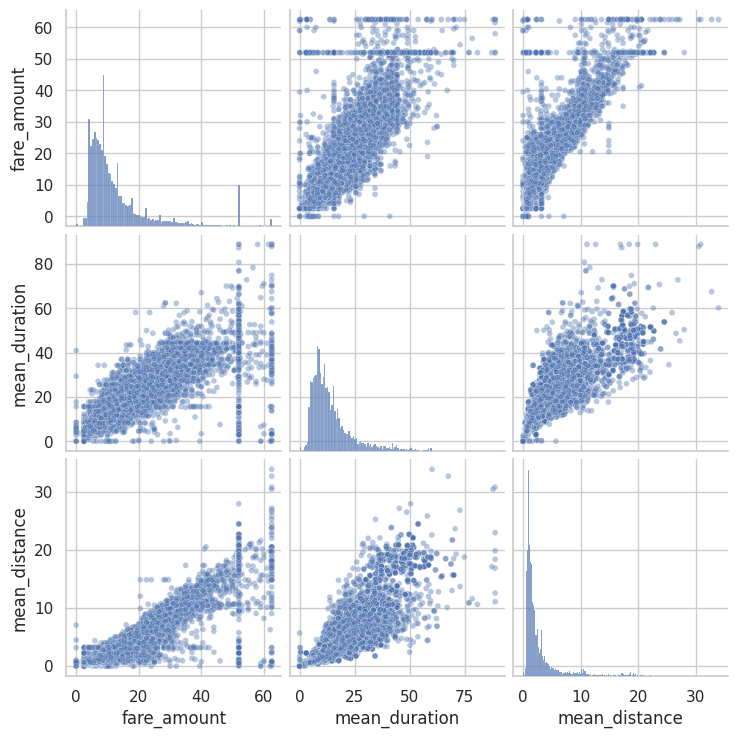

In [ ]:
# Membuat plot pasangan (pairplot) untuk memvisualisasikan hubungan berpasangan antar variabel dalam data.

sns.pairplot(df2[['fare_amount', 'mean_duration', 'mean_distance']],
             plot_kws={'alpha':0.4, 'size':5},
             );

Semua variabel ini menunjukkan korelasi linier satu sama lain.

### Mengidentifikasi korelasi

Selanjutnya, dibuat matriks korelasi untuk membantu menentukan variabel yang paling berkorelasi.

In [ ]:
# Membuat matriks korelasi yang berisi korelasi berpasangan antar kolom, menggunakan koefisien korelasi Pearson.
df2.corr(method='pearson')

,VendorID,passenger_count,fare_amount,mean_distance,mean_duration,rush_hour
VendorID,1.000000,0.266463,0.001045,0.004741,0.001876,-0.002874
passenger_count,0.266463,1.000000,0.014942,0.013428,0.015852,-0.022035
fare_amount,0.001045,0.014942,1.000000,0.910185,0.859105,-0.020075
mean_distance,0.004741,0.013428,0.910185,1.000000,0.874864,-0.039725
mean_duration,0.001876,0.015852,0.859105,0.874864,1.000000,-0.021583
rush_hour,-0.002874,-0.022035,-0.020075,-0.039725,-0.021583,1.000000


Memvisualisasikan heatmap korelasi dari data tersebut.

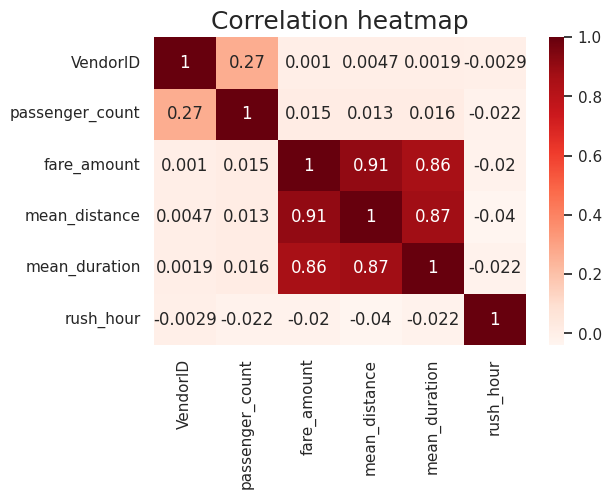

In [ ]:
# Membuat heatmap korelasi
plt.figure(figsize=(6,4))
sns.heatmap(df2.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap',
          fontsize=18)
plt.show()

`mean_duration` dan `mean_distance` keduanya sangat berkorelasi dengan variabel target `fare_amount`. Keduanya juga berkorelasi satu sama lain, dengan korelasi Pearson sebesar 0,87.

Variabel prediktor yang sangat berkorelasi dapat menjadi buruk untuk model regresi linier ketika ingin dapat menarik kesimpulan statistik tentang data dari model tersebut. Namun, variabel prediktor yang berkorelasi masih dapat digunakan untuk membuat prediktor yang akurat jika prediksi itu sendiri lebih penting daripada menggunakan model sebagai alat untuk mempelajari data.

### Memisahkan data menjadi variabel hasil dan fitur.

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 1.0 MB


Menetapkan variabel X dan y. X mewakili fitur dan y mewakili variabel hasil (target).

In [ ]:
# Menghapus kolom target dari fitur-fitur
X = df2.drop(columns=['fare_amount'])

# Menetapkan variabel y
y = df2[['fare_amount']]

# Menampilkan beberapa baris pertama
X.head()

,VendorID,passenger_count,mean_distance,mean_duration,rush_hour
0,2,6,3.521667,22.847222,0
1,1,1,3.108889,24.470370,0
2,1,1,0.881429,7.250000,1
3,2,1,3.700000,30.250000,0
4,2,1,4.435000,14.616667,0


### Pra pemrosesan data

Variabel kategorikal yang dikodekan secara dummy

In [ ]:
# Mengubah VendorID ke string
X['VendorID'] = X['VendorID'].astype(str)

# Get dummies
X = pd.get_dummies(X, drop_first=True)
X.head()

,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
0,6,3.521667,22.847222,0,True
1,1,3.108889,24.470370,0,False
2,1,0.881429,7.250000,1,False
3,1,3.700000,30.250000,0,True
4,1,4.435000,14.616667,0,True


### Memisahkan data menjadi set pelatihan dan set pengujian

Membuat set data pelatihan dan pengujian. Set data pengujian harus berisi 20% dari total sampel. Mengatur `random_state=0`.

In [ ]:
# Membuat set training dan testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Standardisasi data

Menggunakan `StandardScaler()`, `fit()`, dan `transform()` untuk menstandarisasi variabel `X_train`. Menetapkan hasilnya ke variabel bernama `X_train_scaled`.

In [ ]:
# Menstandarisasikan variabel X
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
print('X_train scaled:', X_train_scaled)

X_train scaled: [[-0.50301524  0.8694684   0.17616665 -0.64893329  0.89286563]
 [-0.50301524 -0.60011281 -0.69829589  1.54099045  0.89286563]
 [ 0.27331093 -0.47829156 -0.57301906 -0.64893329 -1.11998936]
 ...
 [-0.50301524 -0.45121122 -0.6788917  -0.64893329 -1.11998936]
 [-0.50301524 -0.58944763 -0.85743597  1.54099045 -1.11998936]
 [ 1.82596329  0.83673851  1.13212101 -0.64893329  0.89286563]]


### Melatih model

Membuat instance model dan latih dengan data pelatihan.

In [ ]:
# Menyesuaikan model dengan data pelatihan.
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

### Evaluasi model

### Data pelatihan

Mengevaluasi kinerja model dengan menghitung jumlah kuadrat residual dan skor varians yang dijelaskan (R^2). Menghitung Kesalahan Mutlak Rata-rata (Mean Absolute Error), Kesalahan Kuadrat Rata-rata (Mean Squared Error), dan Akar Kesalahan Kuadrat Rata-rata (Root Mean Squared Error).

In [ ]:
# Evaluasi kinerja model pada data training
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8398434585044773
R^2: 0.8398434585044773
MAE: 2.186666416775414
MSE: 17.88973296349268
RMSE: 4.229625629236313


### Data Uji

Menghitung metrik yang sama pada data uji. Untuk menskalakan data `X_test` menggunakan penskala yang telah disesuaikan dengan data pelatihan. Tidak disesuaikan kembali penskala ke data pengujian, cukup ditransformasikan saja. Diberi nama hasilnya `X_test_scaled`.

In [ ]:
# Skalakan data X_test
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Evaluasi kinerja model pada data testing
r_sq_test = lr.score(X_test_scaled, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.8682583641795454
R^2: 0.8682583641795454
MAE: 2.1336549840593864
MSE: 14.326454156998942
RMSE: 3.7850302716093225


Performa model tinggi pada set pelatihan dan pengujian, menunjukkan bahwa terdapat sedikit bias dalam model dan model tersebut tidak mengalami overfitting. Bahkan, skor pengujian lebih baik daripada skor pelatihan.

Untuk data pengujian, R² sebesar 0,868 berarti bahwa 86,8% varians dalam variabel `fare_amount` dijelaskan oleh model.

Kesalahan absolut rata-rata (mean absolute error) informatif di sini karena, untuk tujuan model, kesalahan dua tidak lebih buruk dari dua kali lipat kesalahan satu.

### Hasil

In [ ]:
# Membuat dataframe `results`.
results = pd.DataFrame(data={'actual': y_test['fare_amount'],
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
5818,14.0,12.356503,1.643497
18134,28.0,16.314595,11.685405
4655,5.5,6.726789,-1.226789
7378,15.5,16.227206,-0.727206
13914,9.5,10.536408,-1.036408


### Memvisualisasikan hasil model

# Membuat scatterplot untuk memvisualisasikan `actual` vs. `predicted`.

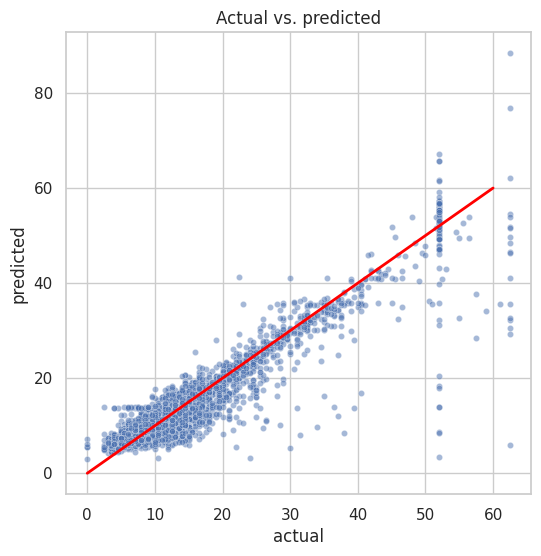

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
                y='predicted',
                data=results,
                s=20,
                alpha=0.5,
                ax=ax
)
# Menggambar garis x=y untuk menunjukkan apa yang akan terjadi jika model tersebut sempurna
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Actual vs. predicted');

Memvisualisasikan distribusi `residual` menggunakan histogram.

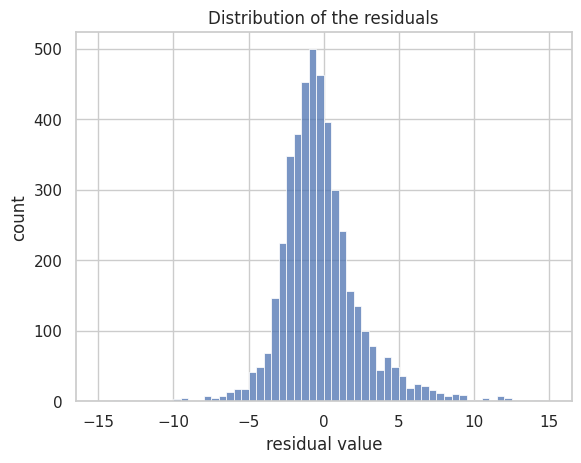

In [ ]:
sns.histplot(results['residual'], bins=np.arange(-15,15.5,0.5))
plt.title('Distribution of the residuals')
plt.xlabel('residual value')
plt.ylabel('count');

In [ ]:
results['residual'].mean()

np.float64(-0.01544262152868054)

**Catatan:** Distribusi residual mendekati normal dan memiliki rata-rata -0,015. Residual mewakili varians dalam variabel hasil yang tidak dijelaskan oleh model. Distribusi normal di sekitar nol adalah baik, karena menunjukkan bahwa kesalahan model terdistribusi secara merata dan tidak bias.

Membuat scatterplot `residuals` terhadap `predicted`.

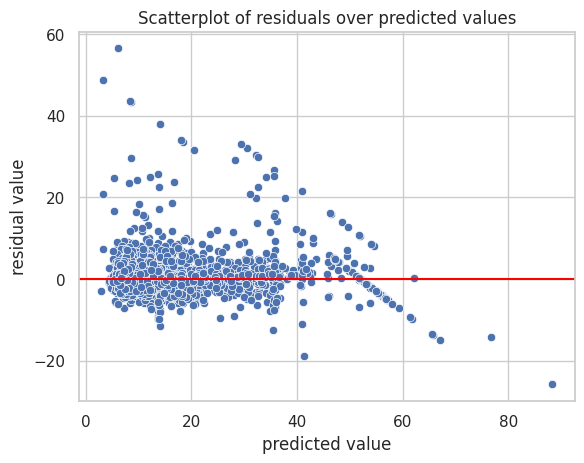

In [ ]:
sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Scatterplot of residuals over predicted values')
plt.xlabel('predicted value')
plt.ylabel('residual value')
plt.show()

**Catatan:** Sisaan model terdistribusi secara merata di atas dan di bawah nol, kecuali garis miring dari sudut kiri atas ke sudut kanan bawah, yang diketahui merupakan nilai maksimum yang diestimasi sebesar 62,50 dan tarif tetap sebesar $52 untuk perjalanan ke bandara JFK.

### Koefisien

Menggunakan atribut `coef_` untuk mendapatkan koefisien model. Koefisien akan ditampilkan sesuai urutan fitur yang digunakan untuk melatih model.

In [ ]:
coefficients = pd.DataFrame(lr.coef_, columns=X.columns)
coefficients

,passenger_count,mean_distance,mean_duration,rush_hour,VendorID_2
0,0.030825,7.133867,2.812115,0.110233,-0.054373


Koefisien tersebut menunjukkan bahwa `mean_distance` adalah fitur dengan bobot terbesar dalam prediksi akhir model. Kesalahpahaman umum adalah bahwa untuk setiap mil yang ditempuh, jumlah tarif meningkat rata-rata sebesar \$7,13. Ini salah. Perlu diingat, data yang digunakan untuk melatih model telah distandarisasi dengan `StandardScaler()`. Dengan demikian, satuannya bukan lagi mil. Dengan kata lain, tidak dapat dinyatakan "untuk setiap mil yang ditempuh...", seperti yang dinyatakan di atas. Interpretasi yang benar dari koefisien ini adalah: dengan mengontrol variabel lain, *untuk setiap perubahan +1 dalam deviasi standar*, jumlah tarif meningkat rata-rata sebesar \$7,13.

Perlu diperhatikan juga bahwa karena beberapa fitur yang sangat berkorelasi tidak dihilangkan, interval kepercayaan dari penilaian ini lebih lebar.

Jadi, perlu diterjemahkan kembali ini ke mil, bukan deviasi standar (yaitu, kembalikan skala data).

1. Menghitung deviasi standar dari `mean_distance` dalam data `X_train`.

2. Membagi koefisien (7.133867) dengan hasilnya untuk mendapatkan interpretasi yang lebih intuitif.

In [ ]:
# 1. Menghitung simpangan baku (SD) dari `mean_distance` pada data X_train
print(X_train['mean_distance'].std())

# 2. Membagi koefisien model dengan simpangan baku
print(7.133867 / X_train['mean_distance'].std())

3.574812975256415
1.9955916713344426


Interpretasi: untuk setiap 3,57 mil yang ditempuh, tarif meningkat rata-rata sebesar 7,13. Atau, berkurang: untuk setiap 1 mil yang ditempuh, tarif meningkat rata-rata sebesar $2,00.

### Kesimpulan
* Regresi linier berganda adalah alat yang ampuh untuk memperkirakan variabel dependen kontinu dari beberapa variabel independen.

* Analisis data eksplorasi berguna untuk memilih fitur numerik dan kategorikal untuk regresi linier berganda.

* Menyesuaikan model regresi linier berganda mungkin memerlukan uji coba dan kesalahan untuk memilih variabel yang sesuai dengan model yang akurat sambil mempertahankan asumsi model (atau tergantung pada kasus penggunaan).